In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 1. Análisis Inicial

Cargamos la matriz del sensor y reportamos su **tamaño** y **rango dinámico** (mínimo y máximo).

In [2]:
data = [
    [10, 11, 12, 80, 82],
    [255, 10, 12, 81, 83],
    [9,  10, 11, 82, 84],
    [8,   9,  0, 85, 86],
    [7,   8,  9, 86, 88]
]

imagen_original = np.array(data, dtype=np.float32)

def howis(img, nombre='Imagen'):
    print(f'=== {nombre} ===')
    print(f'  Tamaño  : {img.shape[0]} filas x {img.shape[1]} columnas')
    print(f'  Minimo  : {np.min(img)}')
    print(f'  Maximo  : {np.max(img)}')
    print()

howis(imagen_original, 'Sensor termico original')

=== Sensor termico original ===
  Tamaño  : 5 filas x 5 columnas
  Minimo  : 0.0
  Maximo  : 255.0



**Interpretación:**  
La matriz es de **5x5 píxeles**. El rango esperado para esta escena sería estrecho (zona fría ~7-12, zona caliente ~80-88).  
Sin embargo el rango va de **0 a 255**, lo que revela dos anomalías:

| Posición | Valor | Tipo de ruido |
|----------|-------|---------------|
| (1, 0)   | 255   | Píxel quemado (saturado) |
| (3, 2)   | 0     | Píxel muerto (apagado)   |

## 2. Tratamiento del Ruido

El **255** está justo al lado de la semilla en (1,1) cuyo valor real es ~10.  
Si aplicáramos solo el filtro Gaussiano sin limpiar antes el 255, ese valor extremo se promediaría con sus vecinos y el píxel de la semilla quedaría con un valor de ~41 en lugar de ~10.  
Al correr Region Growing desde una semilla de valor 41 con umbral ±5, el algoritmo solo encontraría píxeles con valores entre 36 y 46, dejando fuera la mayor parte de la zona fría real. **La segmentación fallaría.**

### Estrategia de dos pasos

1. **Filtro de mediana:** elimina outliers extremos (255 y 0) reemplazándolos por el valor del medio de su vecindario. Es el método ideal para ruido tipo sal-y-pimienta.
2. **Filtro Gaussiano 3x3:** suaviza la imagen resultante de forma natural, con más peso al centro que a los extremos (kernel 1/16 de clase).

In [4]:
# ─── Paso 1: Filtro de mediana ────────────────────────────────────────────────
# ksize=3 toma ventanas 3x3 y reemplaza cada píxel por el valor del medio
# Esto elimina los picos extremos (255 y 0) sin arrastrar su valor al promedio

imagen_sin_outliers = cv2.medianBlur(imagen_original.astype(np.uint8), 3)

print('Imagen tras el filtro de mediana (outliers eliminados):')
print(imagen_sin_outliers)
print()
howis(imagen_sin_outliers.astype(np.float32), 'Tras mediana')

Imagen tras el filtro de mediana (outliers eliminados):
[[10 11 12 80 82]
 [10 11 12 81 82]
 [ 9 10 11 82 84]
 [ 8  9 10 84 86]
 [ 8  8  9 86 86]]

=== Tras mediana ===
  Tamaño  : 5 filas x 5 columnas
  Minimo  : 8.0
  Maximo  : 86.0



In [5]:
# ─── Paso 2: Filtro Gaussiano 3x3 ────────────────────────────────────────────
# Kernel igual al de la clase: más peso al centro, menos a los extremos
# La suma de todos los pesos es 1, por lo que no altera el brillo promedio
kernel_gaussiano = (1/16) * np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32)

imagen_suavizada = cv2.filter2D(
    imagen_sin_outliers.astype(np.float32), -1, kernel_gaussiano
)

print('Imagen suavizada (valores redondeados):')
print(np.round(imagen_suavizada, 1))
print()
howis(imagen_suavizada, 'Tras Gaussiano')

Imagen suavizada (valores redondeados):
[[10.5 11.  28.9 63.8 81.2]
 [10.2 10.8 28.8 64.1 81.8]
 [ 9.5 10.  28.6 64.9 83.1]
 [ 8.6  9.1 28.2 65.9 84.8]
 [ 8.2  8.6 28.1 66.4 85.5]]

=== Tras Gaussiano ===
  Tamaño  : 5 filas x 5 columnas
  Minimo  : 8.25
  Maximo  : 85.5



**Resultado:** El rango dinámico pasó de 0-255 a ~8-86.  
La zona fría (columnas 0-2) ahora tiene valores entre 8 y 29, claramente separados de la zona caliente (columnas 3-4) que ronda 64-86.  
La semilla en (1,1) quedó con valor ~10, coherente con la zona fría.

---
## 3. Segmentación por Region Growing

### Decisiones de diseño

- **Semilla (1,1):** valor suavizado ~10, claramente dentro de la zona fría.
- **Umbral ±5:** la zona fría tiene valores 8-12 (diferencia máxima ~4 entre vecinos). Un umbral de 5 acepta todos los píxeles fríos sin cruzar hacia la zona caliente que empieza en ~64.
- **Conectividad 4:** arriba, abajo, izquierda, derecha (igual que en clase).
- **Comparación siempre contra la semilla original**, no contra el promedio de la región: más estable y predecible.

In [6]:
# ─── Implementación de Region Growing ────────────────────────────────────────
def region_growing(imagen, semilla, umbral):
    """
    Hace crecer una region desde la semilla usando conectividad 4.
    Acepta un vecino si |valor_vecino - valor_semilla| <= umbral.
    Devuelve una mascara binaria: 1 = zona segmentada, 0 = resto.
    """
    filas, columnas = imagen.shape
    mascara   = np.zeros((filas, columnas), dtype=np.uint8)
    visitados = np.zeros((filas, columnas), dtype=bool)

    f0, c0 = semilla
    valor_semilla = float(imagen[f0, c0])

    # Iniciamos la cola con la semilla
    cola = [(f0, c0)]
    mascara[f0, c0]   = 1
    visitados[f0, c0] = True

    # Conectividad 4: arriba, abajo, izquierda, derecha
    vecinos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while cola:
        f, c = cola.pop(0)  # tomamos el primer pixel de la cola

        for df, dc in vecinos:
            nf, nc = f + df, c + dc

            if 0 <= nf < filas and 0 <= nc < columnas:  # dentro de la imagen?
                if not visitados[nf, nc]:
                    visitados[nf, nc] = True
                    diferencia = abs(float(imagen[nf, nc]) - valor_semilla)

                    if diferencia <= umbral:    # es suficientemente parecido?
                        mascara[nf, nc] = 1
                        cola.append((nf, nc))  # lo encolamos para seguir creciendo
    return mascara


# ─── Parámetros ───────────────────────────────────────────────────────────────
SEMILLA = (1, 1)
UMBRAL  = 5

mascara_binaria = region_growing(imagen_suavizada, SEMILLA, UMBRAL)

print(f'Semilla {SEMILLA} -> valor suavizado = {imagen_suavizada[SEMILLA[0], SEMILLA[1]]:.1f}')
print(f'Umbral utilizado : +/-{UMBRAL}')
print()
print('Mascara binaria (1 = zona fria segmentada):')
print(mascara_binaria)

Semilla (1, 1) -> valor suavizado = 10.8
Umbral utilizado : +/-5

Mascara binaria (1 = zona fria segmentada):
[[1 1 0 0 0]
 [1 1 0 0 0]
 [1 1 0 0 0]
 [1 1 0 0 0]
 [1 1 0 0 0]]


**Lectura de la máscara:**  
Los `1` identifican exclusivamente la zona fría (izquierda).  
Los `0` corresponden a la zona de transición y a la zona caliente, que quedaron correctamente fuera de la región.

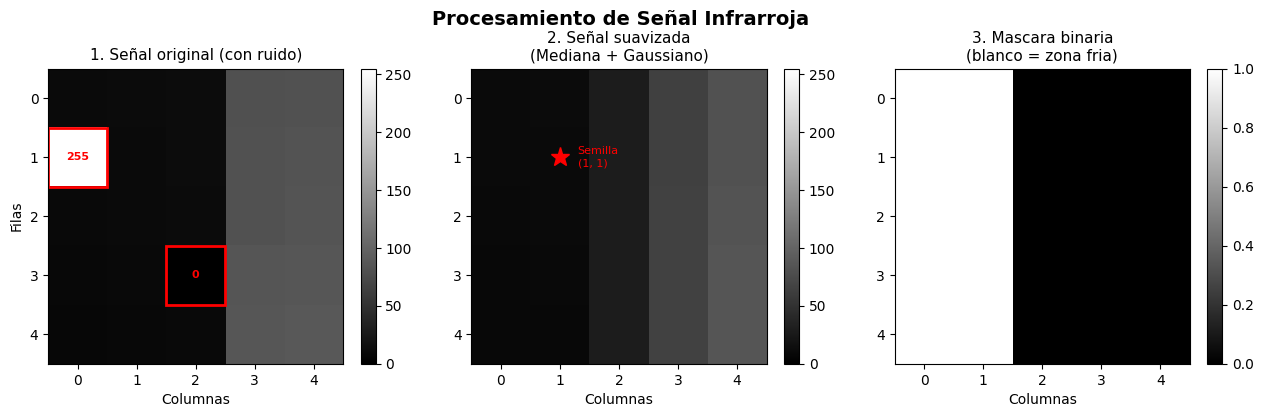

Figura guardada como resultado_desafio.png


In [7]:
fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Procesamiento de Señal Infrarroja', fontsize=14, fontweight='bold')

# Panel 1: imagen original con ruido
im0 = ejes[0].imshow(imagen_original, cmap='gray', vmin=0, vmax=255)
ejes[0].set_title('1. Señal original (con ruido)', fontsize=11)
ejes[0].set_xlabel('Columnas')
ejes[0].set_ylabel('Filas')
ejes[0].add_patch(plt.Rectangle((-0.5, 0.5), 1, 1, fill=False, edgecolor='red', lw=2))
ejes[0].add_patch(plt.Rectangle((1.5, 2.5), 1, 1, fill=False, edgecolor='red', lw=2))
ejes[0].text(0, 1, '255', color='red', ha='center', va='center', fontsize=8, fontweight='bold')
ejes[0].text(2, 3, '0',   color='red', ha='center', va='center', fontsize=8, fontweight='bold')
plt.colorbar(im0, ax=ejes[0], fraction=0.046)

# Panel 2: imagen suavizada con semilla
im1 = ejes[1].imshow(imagen_suavizada, cmap='gray', vmin=0, vmax=255)
ejes[1].set_title('2. Señal suavizada\n(Mediana + Gaussiano)', fontsize=11)
ejes[1].set_xlabel('Columnas')
ejes[1].plot(SEMILLA[1], SEMILLA[0], 'r*', markersize=14)
ejes[1].text(SEMILLA[1]+0.3, SEMILLA[0], f'Semilla\n{SEMILLA}',
             color='red', fontsize=8, va='center')
plt.colorbar(im1, ax=ejes[1], fraction=0.046)

# Panel 3: mascara binaria final
im2 = ejes[2].imshow(mascara_binaria, cmap='gray', vmin=0, vmax=1)
ejes[2].set_title('3. Mascara binaria\n(blanco = zona fria)', fontsize=11)
ejes[2].set_xlabel('Columnas')
plt.colorbar(im2, ax=ejes[2], fraction=0.046)

plt.tight_layout()
plt.savefig('resultado_desafio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada como resultado_desafio.png')

---
## Conclusiones

| Paso | Técnica | Resultado |
|------|---------|----------|
| 1. Análisis | `howis()` | Detectamos rango 0-255: anomalías en (1,0)=255 y (3,2)=0 |
| 2a. Mediana | `cv2.medianBlur(ksize=3)` | Eliminamos outliers extremos (sal y pimienta) |
| 2b. Gaussiano | Kernel 3x3, factor 1/16 | Suavizado fino; rango resultante ~8-86 |
| 3. Segmentación | Region Growing, semilla (1,1), umbral ±5 | Mascara binaria que aisla la zona fria |
| 4. Visualización | `matplotlib` subplots 1x3 | Comparativa: original → suavizada → mascara |

**Sin el tratamiento de ruido**, el valor 255 del píxel quemado desviaría el resultado del suavizado Gaussiano, haciendo que la semilla tomara un valor de ~41 en lugar de ~10. Con ese valor, el Region Growing no podría distinguir la zona fría de la zona de transición y la segmentación fallaría completamente.